# Novin Nekuee 403134029

First of all lets import all necassary libraries for this question

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import tensorflow as tf


In [2]:
file_path = "./assets/Dataset.csv"

data_set = pd.read_csv(file_path)
data_set.head()

,DEPTH,WELL,CALI,CGR,DT,DTC,DTS,GR,NPHI,PE,POTA,RHOB,RT,RXO,SGR,THOR,URAN,LITHOLOGY
0,3694.4036,B,7.9699,21.6712,62.1382,-24.6912,33.3681,28.0000,0.093401,5.1541,1.3150,2.5719,1.4933,1.1596,28.2321,0.8767,0.5973,-999.25
1,3694.5560,B,7.9725,21.2984,61.0942,63.1950,120.1099,25.9846,0.091601,5.2000,1.2971,2.5891,1.7119,1.4645,28.6374,0.8391,0.6958,-999.25
2,3694.7084,B,7.9749,20.3458,60.3646,62.8110,117.6982,24.8265,0.086403,5.0974,1.2525,2.5999,1.9718,1.7356,28.1291,0.7379,0.7501,-999.25
3,3694.8608,B,7.9766,19.5276,59.9658,62.2733,115.6809,24.1915,0.082602,5.0011,1.2125,2.6119,2.3084,2.1589,27.5415,0.6589,0.7839,-999.25
4,3695.0132,B,7.9774,19.2535,59.8785,61.6987,114.4189,24.5139,0.079302,5.0279,1.1942,2.6166,2.5474,2.6491,27.1765,0.6558,0.7639,-999.25


Based on our data we can figure out that our data is multi class, so we need a classification model.

In [3]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13357 entries, 0 to 13356
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DEPTH      13357 non-null  float64
 1   WELL       13357 non-null  object 
 2   CALI       13357 non-null  float64
 3   CGR        13357 non-null  float64
 4   DT         13357 non-null  float64
 5   DTC        13357 non-null  float64
 6   DTS        13357 non-null  float64
 7   GR         13357 non-null  float64
 8   NPHI       13357 non-null  float64
 9   PE         13357 non-null  float64
 10  POTA       13357 non-null  float64
 11  RHOB       13357 non-null  float64
 12  RT         13357 non-null  float64
 13  RXO        13357 non-null  float64
 14  SGR        13357 non-null  float64
 15  THOR       13357 non-null  float64
 16  URAN       13357 non-null  float64
 17  LITHOLOGY  13357 non-null  float64
dtypes: float64(17), object(1)
memory usage: 1.8+ MB


In [4]:
data_set.isnull().sum()

DEPTH        0
WELL         0
CALI         0
CGR          0
DT           0
DTC          0
DTS          0
GR           0
NPHI         0
PE           0
POTA         0
RHOB         0
RT           0
RXO          0
SGR          0
THOR         0
URAN         0
LITHOLOGY    0
dtype: int64

So based on this info, there is no unfill data or `Nan`

In [5]:
data_set.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DEPTH,13357.0,NaN,NaN,NaN,4117.691773,305.008743,3521.8118,3863.8724,4119.4472,4374.185,4697.5778
WELL,13357,2,C,7716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CALI,13357.0,NaN,NaN,NaN,-16.901829,153.668212,-999.25,6.1162,6.5223,8.4407,9.4272
CGR,13357.0,NaN,NaN,NaN,-1.890345,172.086825,-999.25,11.2843,18.5195,29.7024,190.2562
DT,13357.0,NaN,NaN,NaN,24.104997,199.130393,-999.25,53.7265,59.0498,69.2194,98.7809
DTC,13357.0,NaN,NaN,NaN,-551.089782,524.212277,-999.25,-999.25,-999.25,56.4363,98.7809
DTS,13357.0,NaN,NaN,NaN,119.506922,23.968322,33.3681,102.7796,112.0026,128.2963,238.0627
GR,13357.0,NaN,NaN,NaN,9.648733,185.51705,-999.25,23.1097,33.1786,50.8584,201.7274
NPHI,13357.0,NaN,NaN,NaN,-32.67496,177.981344,-999.25,0.025872,0.067858,0.143187,0.382891
PE,13357.0,NaN,NaN,NaN,-29.659666,186.8062,-999.25,5.0868,6.0931,7.3065,11.2303


In [6]:
data_set.columns

Index(['DEPTH', 'WELL', 'CALI', 'CGR', 'DT', 'DTC', 'DTS', 'GR', 'NPHI', 'PE',
       'POTA', 'RHOB', 'RT', 'RXO', 'SGR', 'THOR', 'URAN', 'LITHOLOGY'],
      dtype='object')

So now based on what we know about the log data, -999.25 is Nan ti describe so we should convert them to Nan

In [7]:
data_set = data_set.replace(-999.25, np.nan)

In [8]:
data_set.head()

,DEPTH,WELL,CALI,CGR,DT,DTC,DTS,GR,NPHI,PE,POTA,RHOB,RT,RXO,SGR,THOR,URAN,LITHOLOGY
0,3694.4036,B,7.9699,21.6712,62.1382,-24.6912,33.3681,28.0000,0.093401,5.1541,1.3150,2.5719,1.4933,1.1596,28.2321,0.8767,0.5973,NaN
1,3694.5560,B,7.9725,21.2984,61.0942,63.1950,120.1099,25.9846,0.091601,5.2000,1.2971,2.5891,1.7119,1.4645,28.6374,0.8391,0.6958,NaN
2,3694.7084,B,7.9749,20.3458,60.3646,62.8110,117.6982,24.8265,0.086403,5.0974,1.2525,2.5999,1.9718,1.7356,28.1291,0.7379,0.7501,NaN
3,3694.8608,B,7.9766,19.5276,59.9658,62.2733,115.6809,24.1915,0.082602,5.0011,1.2125,2.6119,2.3084,2.1589,27.5415,0.6589,0.7839,NaN
4,3695.0132,B,7.9774,19.2535,59.8785,61.6987,114.4189,24.5139,0.079302,5.0279,1.1942,2.6166,2.5474,2.6491,27.1765,0.6558,0.7639,NaN


So now lets drop nan data to use our valid data

In [9]:
data_set_cleaned = data_set.dropna()
data_set_cleaned.shape

(1814, 18)

now lets see the boxplot to see if there is any outier data

In [10]:
data_set_cleaned.drop(columns = ["WELL",],inplace=True)
data_set_cleaned

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22408\3811424640.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set_cleaned.drop(columns = ["WELL",],inplace=True)


,DEPTH,CALI,CGR,DT,DTC,DTS,GR,NPHI,PE,POTA,RHOB,RT,RXO,SGR,THOR,URAN,LITHOLOGY
2814,4128.2864,6.2301,64.5480,78.2275,76.5277,149.5135,83.5433,0.217196,3.0936,2.3022,2.6636,3.7167,3.4143,73.0883,9.1764,0.9508,1.0
2815,4128.4388,6.2292,63.7257,80.6160,78.2237,155.4560,86.2239,0.224995,3.3081,2.1008,2.6579,3.3668,3.1081,74.4830,9.7427,1.1977,0.0
2816,4128.5912,6.2287,65.0605,82.9398,80.6751,168.4921,92.3799,0.234794,3.4951,1.9866,2.6395,2.9381,2.7082,74.7791,10.5750,1.0821,0.0
2817,4128.7436,6.2287,66.8170,84.3654,82.9044,182.8134,93.5512,0.244394,3.5860,1.9985,2.6197,2.6121,2.3993,74.2409,11.0262,0.8266,0.0
2818,4128.8960,6.2287,67.4193,85.5507,84.3249,189.8973,91.7495,0.257792,3.6385,2.1397,2.6051,2.4106,2.2258,73.0277,10.6365,0.6244,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4623,4405.3496,6.1036,11.4618,58.1082,58.1061,108.7635,52.9874,0.065687,4.7885,0.6089,2.6281,51.5683,5.0206,28.4151,0.8348,1.8874,3.0
4624,4405.5020,6.1035,11.7984,59.5126,59.4766,110.6828,47.3114,0.088186,5.1448,0.6787,2.5765,30.1476,2.4448,25.9832,0.6537,1.5792,3.0
4625,4405.6544,6.1034,11.6000,60.9175,60.8893,112.5844,39.1178,0.110886,5.5729,0.7278,2.5311,20.4183,1.5793,23.8281,0.4025,1.3614,2.0
4626,4405.8068,6.1035,11.0163,62.3745,62.2827,114.7091,31.4177,0.129788,6.1362,0.7129,2.4973,14.1113,1.0985,22.1958,0.2959,1.2447,2.0


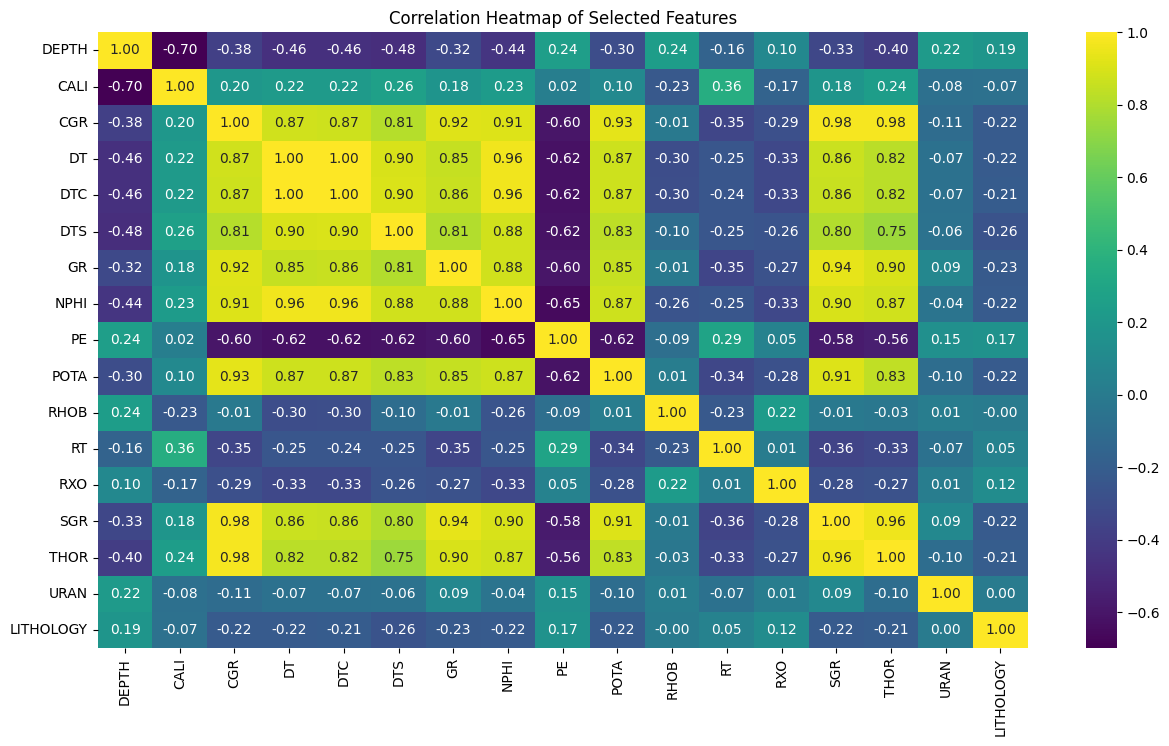

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
sns.heatmap(data_set_cleaned.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap of Selected Features')
plt.show()

Now lets see the linear relation for our target

In [12]:
data_set_cleaned.corr()["LITHOLOGY"].sort_values(ascending=False)

LITHOLOGY    1.000000
DEPTH        0.188384
PE           0.165915
RXO          0.122825
RT           0.054751
URAN         0.002321
RHOB        -0.000352
CALI        -0.069328
THOR        -0.205181
DTC         -0.214160
DT          -0.215720
POTA        -0.215952
SGR         -0.217134
CGR         -0.217370
NPHI        -0.219649
GR          -0.227645
DTS         -0.262243
Name: LITHOLOGY, dtype: float64

So based on above results we can choose our parameters to select our features 

Now lets see the pair plot

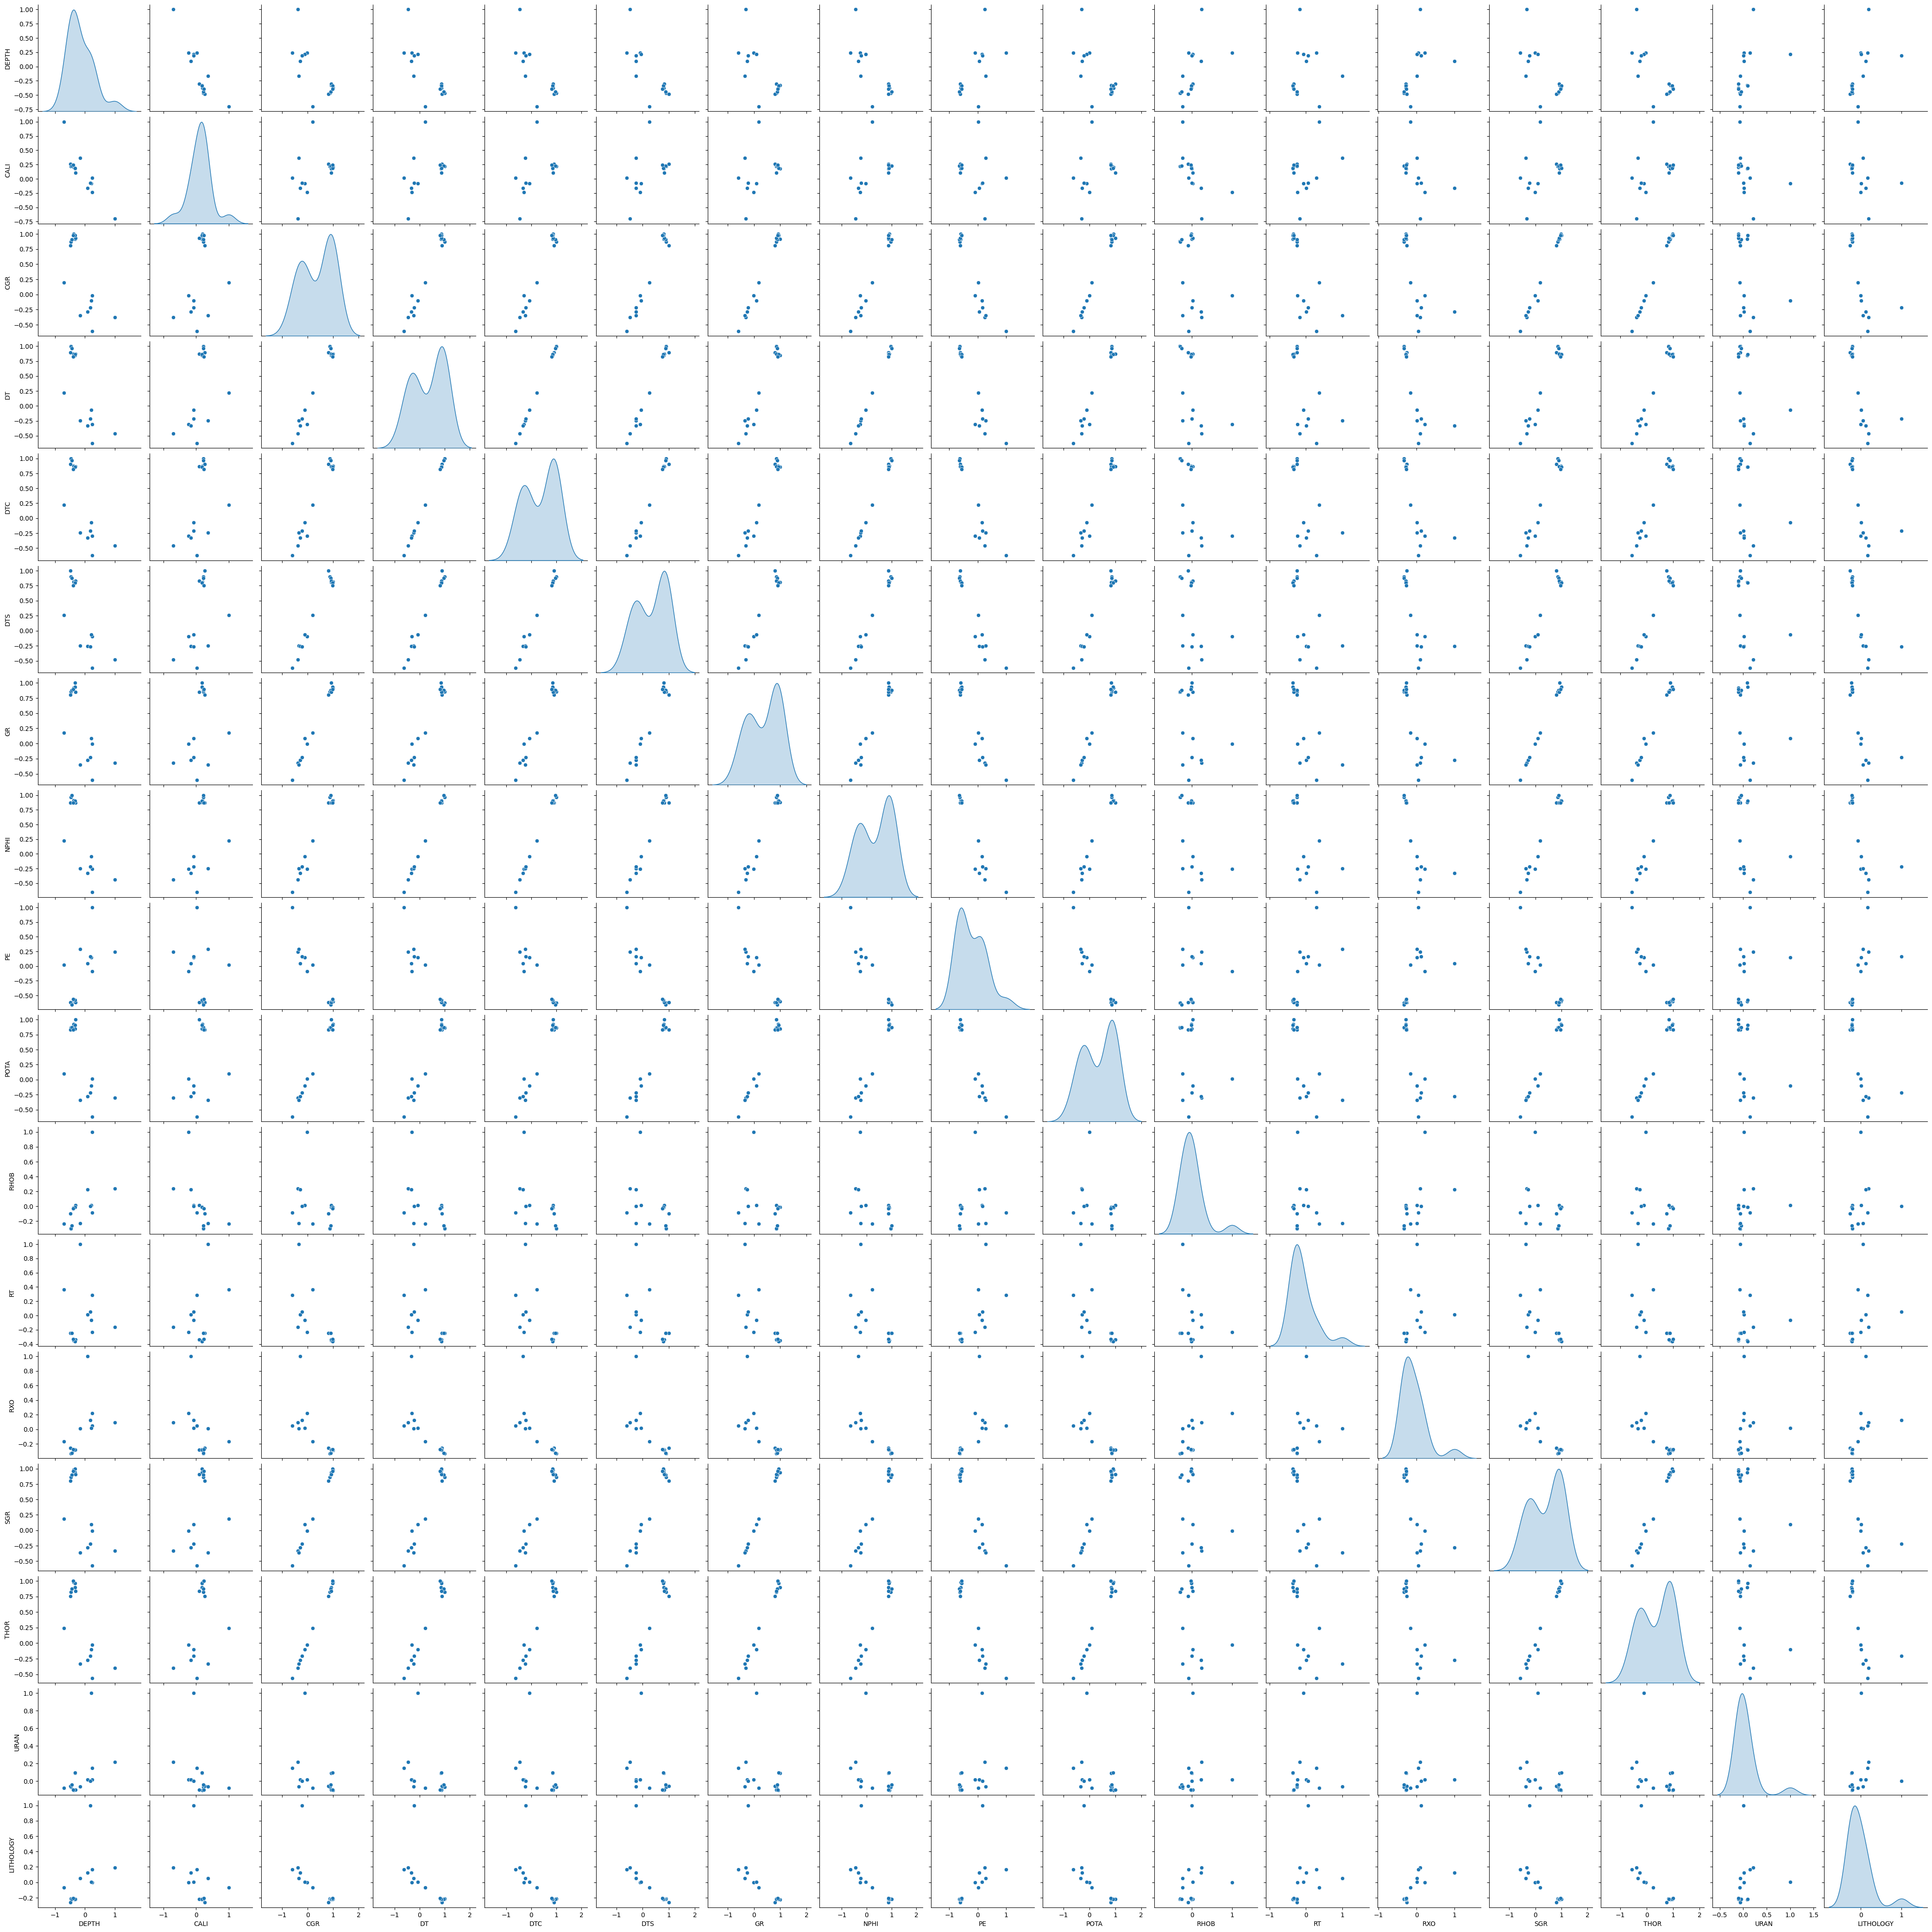

In [13]:
sns.pairplot(data_set_cleaned.corr() , diag_kind='kde')
plt.show()

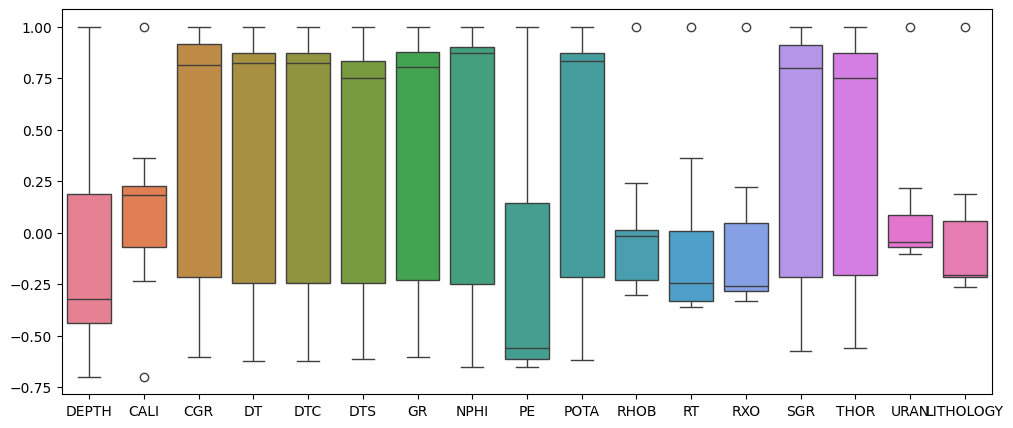

In [14]:
plt.figure(figsize = (12, 5))
sns.boxplot(data_set_cleaned.corr())
plt.show()

So as we see we have many outliers 

In [15]:
def remove_outliers(df):

    cleaned_df = pd.DataFrame(columns = df.columns)

    for col in df.columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR

        col_cleaned = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)][col]

        cleaned_df[col] = col_cleaned
    return cleaned_df

data_set_cleaned = remove_outliers(data_set_cleaned)

In [16]:
print(data_set_cleaned.isnull().sum())
data_set_cleaned.dropna(inplace=True)

DEPTH          0
CALI          35
CGR            0
DT             0
DTC            0
DTS            0
GR             0
NPHI           0
PE             7
POTA           0
RHOB          61
RT           252
RXO          221
SGR            0
THOR           3
URAN          40
LITHOLOGY      0
dtype: int64


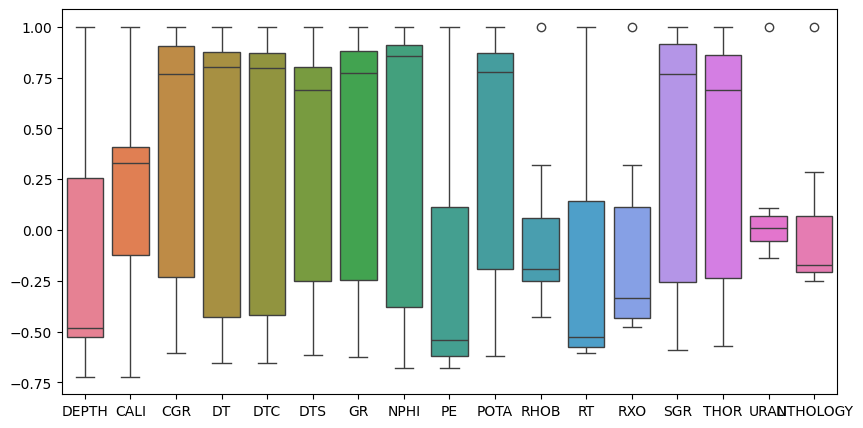

In [17]:
plt.figure(figsize = (10 , 5))
sns.boxplot(data_set_cleaned.corr())
plt.show()

Now lets see how our data are distributed by histogram 

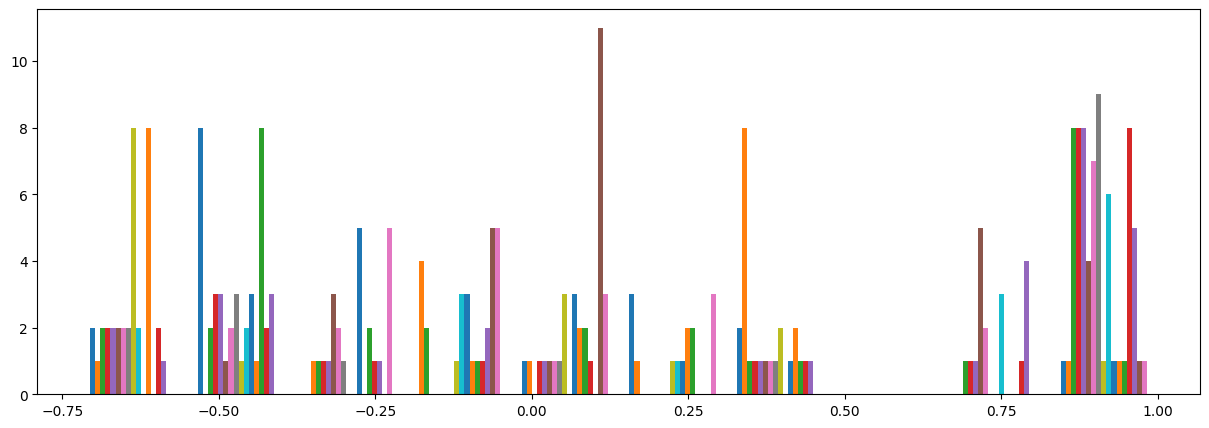

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15,5))
plt.hist(data_set_cleaned.corr())
plt.show()

Now lets Drop our columns and select the target column

In [19]:
TARGET = ["LITHOLOGY"]

COLUMNS = ["DEPTH","DT","GR",'POTA']# Removed due to outliers,'RXO'

X = data_set_cleaned[COLUMNS]
y = data_set_cleaned["LITHOLOGY"]

print(X.shape)

(1276, 4)


In [20]:
print(y.shape)

(1276,)


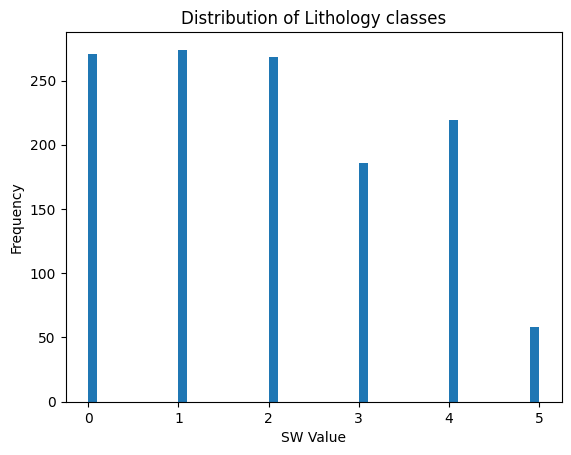

In [21]:
plt.hist(y, bins=50)
plt.title('Distribution of Lithology classes')
plt.xlabel('SW Value')
plt.ylabel('Frequency')
plt.show()

Now lets split our data to train.test,validation

In [22]:
from sklearn.model_selection import train_test_split

X_trains , X_test, y_trains, y_test = train_test_split(X,y, test_size=0.20 , random_state=42)

X_train,X_val , y_train, y_val = train_test_split(X_trains,y_trains, test_size=0.25 , random_state=42) # 0.2 / 0.8 = 0.25

print("\n--- Shapes for train ---")
print(f"X-train = {X_train.shape}")
print(f"y-train = {y_train.shape}")
print("\n--- Shapes for train ---")
print(f"X-test = {X_test.shape}")
print(f"y-test = {y_test.shape}")
print("\n--- Shapes for train ---")
print(f"X-val = {X_val.shape}")
print(f"y-val = {y_val.shape}")



--- Shapes for train ---
X-train = (765, 4)
y-train = (765,)

--- Shapes for train ---
X-test = (256, 4)
y-test = (256,)

--- Shapes for train ---
X-val = (255, 4)
y-val = (255,)


Now lets Normalize our data with min-max scaler

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)



In [24]:
X_train

array([[3.24725275e-01, 4.95265596e-01, 8.84873768e-01, 3.84995349e-01],
       [6.92307692e-02, 8.36340524e-01, 8.09924867e-01, 7.52157039e-01],
       [7.65384615e-01, 1.74468945e-01, 2.28374335e-01, 2.17564230e-01],
       ...,
       [5.49450549e-04, 6.45308005e-01, 5.86414510e-01, 5.12268660e-01],
       [4.00000000e-01, 5.74625531e-01, 9.17431510e-01, 6.27802547e-01],
       [2.35164835e-01, 7.31867938e-01, 9.99576555e-01, 5.04153703e-01]],
      shape=(765, 4))

In [25]:
X_test

array([[0.05824176, 0.6755602 , 0.77615314, 0.51842705],
       [0.02802198, 0.77885208, 0.71351795, 0.58908811],
       [0.04450549, 0.59053666, 0.52393147, 0.25441832],
       ...,
       [0.8478022 , 0.25200626, 0.10476472, 0.04432755],
       [0.86153846, 0.2046096 , 0.09747036, 0.0863457 ],
       [0.23846154, 0.40289684, 0.68165092, 0.42900215]], shape=(256, 4))

In [26]:
X_val

array([[0.39120879, 0.38756238, 0.76539877, 0.25008821],
       [0.04395604, 0.59943932, 0.53276101, 0.24537319],
       [0.06538462, 0.78708967, 0.78863188, 0.60413125],
       ...,
       [0.02197802, 0.67156348, 0.5020178 , 0.49796324],
       [0.20824176, 0.76274943, 0.62061209, 0.7596305 ],
       [0.68846154, 0.10401167, 0.10181429, 0.14045611]], shape=(255, 4))

There is no need to scale y_train, test, valc Due to it is multi class Problem 

### Model


Now lets create our model 


In [27]:
import random

def generate_nn_architecture(student_number, n_selected_features, num_classes):
    # student_number: your student number
    # n_selected_features: number of selected input features
    # num_classes: number of classes in the target 
    
    random.seed(student_number)
    nn_architecture = []  
    num_layers = random.randint(4, 5)
    input_dim = n_selected_features 
    for i in range(num_layers):
       
        output_dim = random.randint(5, 15)
       
        activation = 'Should be set by student'
       
        nn_architecture.append({"input_dim": input_dim, "output_dim": output_dim, "activation": activation})

        input_dim = output_dim
    

    nn_architecture.append({"input_dim": input_dim, "output_dim": num_classes, "activation": "Should be set by student"})
    
    return nn_architecture

student_number = 403134029
n_select = len(COLUMNS)
class_num = 6
layers_generate = generate_nn_architecture(student_number, n_select, class_num)
layers_generate

[{'input_dim': 4, 'output_dim': 9, 'activation': 'Should be set by student'},
 {'input_dim': 9, 'output_dim': 15, 'activation': 'Should be set by student'},
 {'input_dim': 15, 'output_dim': 10, 'activation': 'Should be set by student'},
 {'input_dim': 10, 'output_dim': 12, 'activation': 'Should be set by student'},
 {'input_dim': 12, 'output_dim': 6, 'activation': 'Should be set by student'}]

In [28]:
from tensorflow.keras.utils import to_categorical

num_classes = 6

y_train_oh = to_categorical(y_train.squeeze(), num_classes=num_classes)
y_val_oh   = to_categorical(y_val.squeeze(),   num_classes=num_classes)

In [29]:
from keras.models import Sequential # type: ignore
from keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization # type: ignore
from tensorflow.keras.optimizers import Adam,SGD # type: ignore
from tensorflow.keras import regularizers  # pyright: ignore[reportMissingImports]
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau  # pyright: ignore[reportUnusedImport]

n_features_in = X_train.shape[1]
n_features_out = 6

def build_model_from_architecture(architecture, learning_rate=0.001):
    model = Sequential()
    
    for i, layer_params in enumerate(architecture):
        if i == 0:
            model.add(Dense(
                units=layer_params['output_dim'],
                activation="selu",
                input_dim=layer_params['input_dim']
            ))
        elif i == 4: 
            model.add(Dropout(0.2))
            model.add(Dense(
                units=layer_params['output_dim'],
                activation="softmax",
                kernel_initializer='lecun_normal', 
                kernel_regularizer=regularizers.l2(0.002)
            ))
        else:
            model.add(Dense(
                units=layer_params['output_dim'],
                activation="selu"
            ))
            
    optimizer = SGD(learning_rate=learning_rate)
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    return model

model = build_model_from_architecture(layers_generate, learning_rate=0.001)

d:\Users\ASUS\Desktop\Final Exam (AI in petroleum)\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 9)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            78 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 565 (2.21 KB)

 Trainable params: 565 (2.21 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
    )

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

history = model.fit(
    X_train,
    y_train_oh,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val_oh),
    callbacks=[lr_reducer, early_stopper],
    verbose=1
)

Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1569 - loss: 1.9716 - val_accuracy: 0.1922 - val_loss: 1.9055 - learning_rate: 0.0010
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1686 - loss: 1.9127 - val_accuracy: 0.1725 - val_loss: 1.8632 - learning_rate: 0.0010
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1725 - loss: 1.8745 - val_accuracy: 0.1922 - val_loss: 1.8312 - learning_rate: 0.0010
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1922 - loss: 1.8363 - val_accuracy: 0.2196 - val_loss: 1.8059 - learning_rate: 0.0010
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2288 - loss: 1.8075 - val_accuracy: 0.2588 - val_loss: 1.7843 - learning_rate: 0.0010
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2418 - loss: 1.7825 - val_accuracy: 0.2667 - val_loss: 1.7649 - learning_rate: 0.0010
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2536 - loss: 1.7604 - val_ac

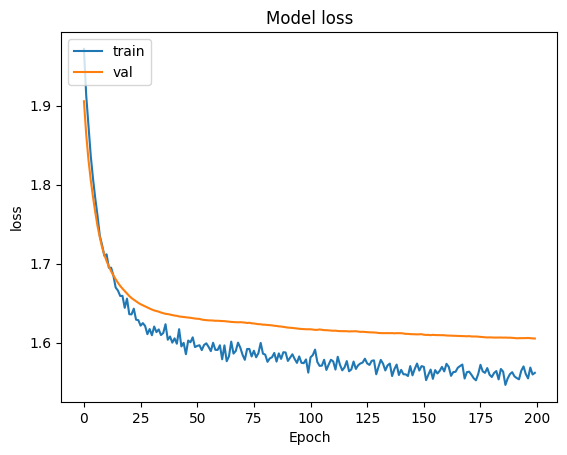

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model loss')
plt.ylabel ('loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [33]:
import numpy as np

y_pred_prob = model.predict(X_val)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_val_oh, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [34]:
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Accuracy: 0.3686274509803922

Classification Report:
              precision    recall  f1-score   support

           0     0.4557    0.6545    0.5373        55
           1     0.3333    0.3400    0.3366        50
           2     0.3306    0.7455    0.4581        55
           3     0.0000    0.0000    0.0000        37
           4     0.0000    0.0000    0.0000        47
           5     0.0000    0.0000    0.0000        11

    accuracy                         0.3686       255
   macro avg     0.1866    0.2900    0.2220       255
weighted avg     0.2350    0.3686    0.2807       255



d:\Users\ASUS\Desktop\Final Exam (AI in petroleum)\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Users\ASUS\Desktop\Final Exam (AI in petroleum)\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Users\ASUS\Desktop\Final Exam (AI in petroleum)\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

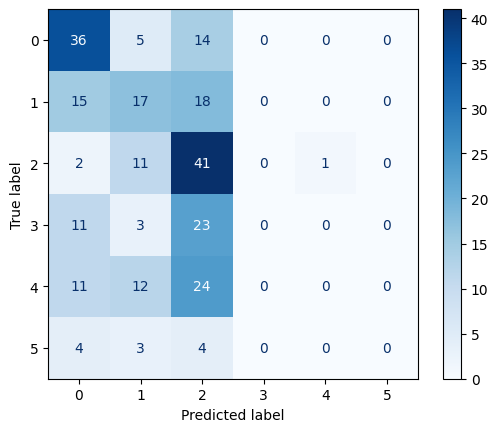

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Accuracy all: 0.3686274509803922
Class0 -> Precision: 0.456, Recall: 0.655, F1-score: 0.537, Support: 55.0
Class1 -> Precision: 0.333, Recall: 0.340, F1-score: 0.337, Support: 50.0
Class2 -> Precision: 0.331, Recall: 0.745, F1-score: 0.458, Support: 55.0
Class3 -> Precision: 0.000, Recall: 0.000, F1-score: 0.000, Support: 37.0
Class4 -> Precision: 0.000, Recall: 0.000, F1-score: 0.000, Support: 47.0
Class5 -> Precision: 0.000, Recall: 0.000, F1-score: 0.000, Support: 11.0

👎 Weakest class3 w/ F1-score = 0.000


d:\Users\ASUS\Desktop\Final Exam (AI in petroleum)\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Users\ASUS\Desktop\Final Exam (AI in petroleum)\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Users\ASUS\Desktop\Final Exam (AI in petroleum)\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

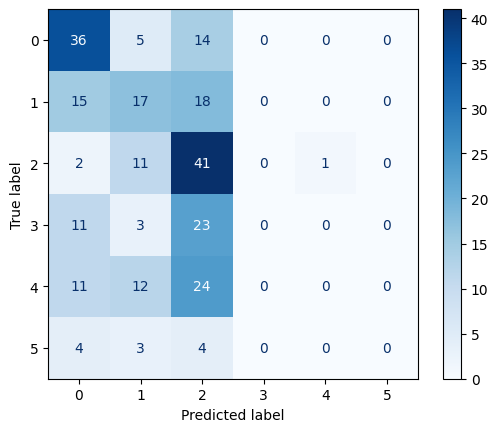

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val_oh, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')

report = classification_report(y_true, y_pred, output_dict=True, digits=4)

print("Accuracy all:", report['accuracy'])


for cls, metrics in report.items():
    if cls.isdigit():
        print(f"Class{cls} -> Precision: {metrics['precision']:.3f}, "
              f"Recall: {metrics['recall']:.3f}, "
              f"F1-score: {metrics['f1-score']:.3f}, "
              f"Support: {metrics['support']}")

f1_scores = {cls: m['f1-score'] for cls, m in report.items() if cls.isdigit()}

worst_class = min(f1_scores, key=f1_scores.get)
print(f"\n👎 Weakest class{worst_class} w/ F1-score = {f1_scores[worst_class]:.3f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


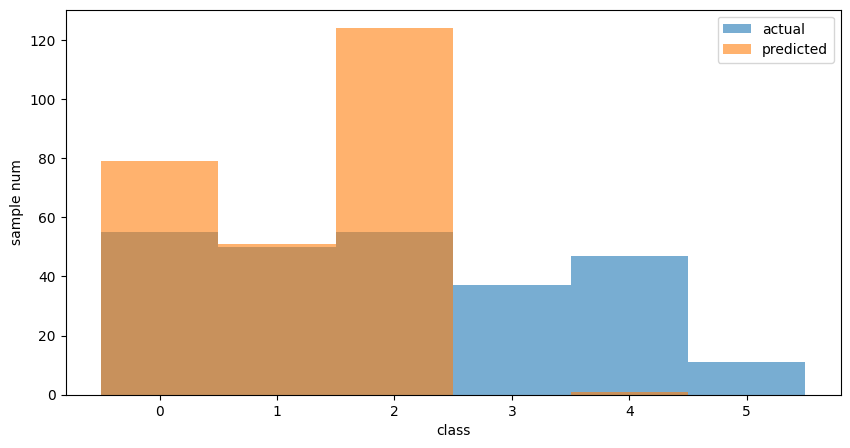

In [37]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val_oh, axis=1)

classes = np.arange(num_classes)

plt.figure(figsize=(10,5))

plt.hist(y_true, bins=np.arange(num_classes+1)-0.5, alpha=0.6, label='actual')

plt.hist(y_pred, bins=np.arange(num_classes+1)-0.5, alpha=0.6, label='predicted')

plt.xticks(classes)
plt.xlabel("class")
plt.ylabel("sample num")
plt.legend()
plt.show()


It means that we did it correctly
